### Neural Network to Predict a Successful Vaginal Birth After C-Section

Now we'll test a neural network to see if it achieves better accuracy.

In [1]:
from pickle import load

x_train = load(open("../../../data/processed/vbac/filtered_x_train_prepared.pkl", "rb"))
x_test = load(open("../../../data/processed/vbac/filtered_x_test_prepared.pkl", "rb"))
y_test = load(open("../../../data/processed/vbac/y_test.pkl", "rb"))
y_train = load(open("../../../data/processed/vbac/y_train.pkl", "rb"))

In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

nn_model = Sequential()
nn_model.add(Dense(64, input_dim=x_train.shape[1], activation="relu"))
nn_model.add(Dense(32, activation="relu"))
nn_model.add(Dense(1, activation="sigmoid"))

nn_model.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])

nn_model.fit(
    x_train, y_train, epochs=20, batch_size=64, validation_data=(x_test, y_test)
)

Epoch 1/20


c:\Users\Alexa\dev\natality-stats\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


6925/6925 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step - accuracy: 0.9193 - loss: 0.2299 - val_accuracy: 0.9233 - val_loss: 0.2187
Epoch 2/20
6925/6925 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step - accuracy: 0.9240 - loss: 0.2153 - val_accuracy: 0.9242 - val_loss: 0.2145
Epoch 3/20
6925/6925 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step - accuracy: 0.9250 - loss: 0.2120 - val_accuracy: 0.9258 - val_loss: 0.2106
Epoch 4/20
6925/6925 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - accuracy: 0.9260 - loss: 0.2100 - val_accuracy: 0.9254 - val_loss: 0.2106
Epoch 5/20
6925/6925 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step - accuracy: 0.9261 - loss: 0.2090 - val_accuracy: 0.9262 - val_loss: 0.2094
Epoch 6/20
6925/6925 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step - accuracy: 0.9265 - loss: 0.2082 - val_accuracy: 0.9263 - val_loss: 0.2095
Epoch 7/20
6925/6925 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step - accuracy: 0.9269 - loss: 0.2078 - val_accuracy: 0.9264 - val_loss: 0.2083
Epoch 8/20
6925/6925 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step - accuracy: 0.9267 - loss: 0.2074 - val_accurac

In [12]:
predictions = nn_model.predict(x_test)
predictions = (predictions > 0.5).astype(int)

3463/3463 ━━━━━━━━━━━━━━━━━━━━ 2s 495us/step


Our model achieved an r-squared score of .397.

In [13]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, predictions)

r2

0.39701800279602817

Our confusion matrix indicates that our model has a high false-negative rate, similar to our previous models.

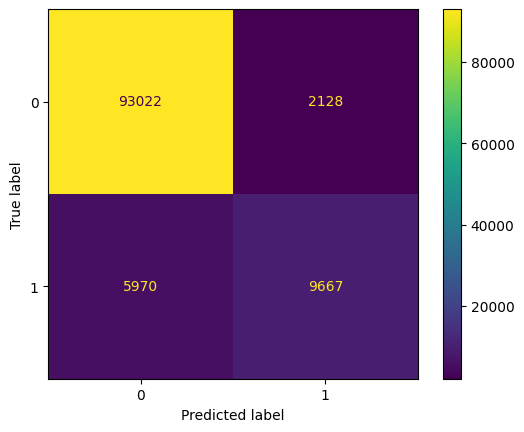

In [14]:
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot()
plt.show()

In [10]:
nn_model.save("../../../models/vbac/nn_model.keras")

### Conclusion

Our neural network is able to predict VBAC outcomes with moderate accuracy.